<a href="https://colab.research.google.com/github/anushkadhar27-cpu/OIBSIP/blob/main/DataScience_Task4_SpamDetectionWithMachineLearning%2Cipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--- Class Distribution Check ---
Class 'ham': 6 entries (60.00%)
Class 'spam': 4 entries (40.00%)


--- Model Evaluation ---

[Multinomial Naive Bayes]
Accuracy : 0.6667
Precision: 0.5000
Recall   : 1.0000
F1-Score : 0.6667
Confusion Matrix:
[[1 1]
 [0 1]]

[Logistic Regression]
Accuracy : 0.6667
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
Confusion Matrix:
[[2 0]
 [1 0]]


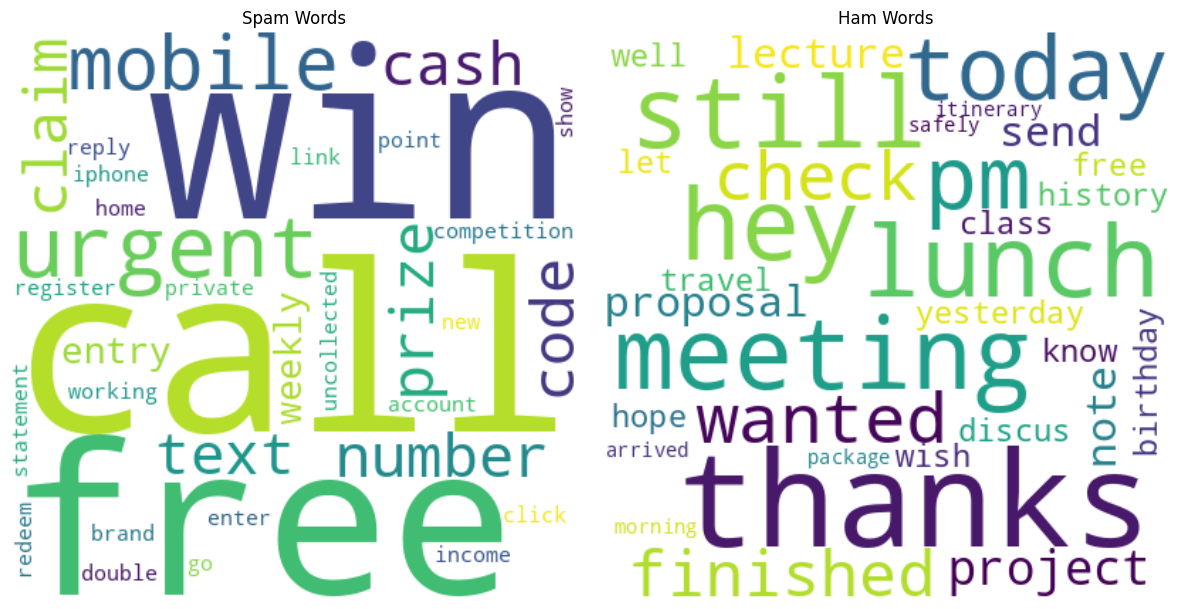

In [ ]:
# ==========================================
# TASK 4: Email Spam Detection with ML
# ==========================================


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression



nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')


try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("WordCloud library not installed. Run 'pip install wordcloud' to enable visualizations.")



data = {
    'label': ['ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham'],
    'text': [
        "Hey, are we still meeting up for lunch today at 1 PM?",
        "URGENT! Your mobile number has won a £2,000 cash prize! Call 09061701461 claim code text WIN.",
        "Just wanted to check if you finished the project proposal.",
        "FREE entry into our weekly competition to win a brand new iPhone. Reply GO to enter.",
        "Can you send me the lecture notes from yesterday's history class?",
        "Double your income working from home! Click this link now to register for free.",
        "Thanks for the birthday wishes, hope you are doing well!",
        "Let me know when you are free to discuss the travel itinerary.",
        "PRIVATE! Your account statement shows uncollected points. Call now to redeem.",
        "The package arrived safely this morning. Thanks again!"
    ]
}
df = pd.DataFrame(data)

# Print class distributions
print("--- Class Distribution Check ---")
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

for label in counts.index:
    print(f"Class '{label}': {counts[label]} entries ({percentages[label]:.2f}%)")
print("\n")


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize, remove stopwords, and apply lemmatization
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(cleaned_words)


df['cleaned_text'] = df['text'].apply(preprocess_text)


X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)


tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression()
}

print("--- Model Evaluation ---")
for name, clf in classifiers.items():

    clf.fit(X_train_tfidf, y_train)

    y_pred = clf.predict(X_test_tfidf)


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='spam', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='spam', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='spam', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

    print(f"\n[{name}]")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")


if HAS_WORDCLOUD:
    spam_words = " ".join(df[df['label'] == 'spam']['cleaned_text'])
    ham_words = " ".join(df[df['label'] == 'ham']['cleaned_text'])

    plt.figure(figsize=(12, 6))


    plt.subplot(1, 2, 1)
    spam_wc = WordCloud(width=400, height=400, background_color='white').generate(spam_words)
    plt.imshow(spam_wc, interpolation='bilinear')
    plt.title('Spam Words')
    plt.axis('off')


    plt.subplot(1, 2, 2)
    ham_wc = WordCloud(width=400, height=400, background_color='white').generate(ham_words)
    plt.imshow(ham_wc, interpolation='bilinear')
    plt.title('Ham Words')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
